In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                           classification_report, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import time

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [ ]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names
target_names_wine = wine.target_names

print("Описание набора данных Wine:")
print(wine.DESCR[:800])

Описание набора данных Wine:
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:        


In [ ]:
df_wine = pd.DataFrame(X_wine, columns=feature_names_wine)
df_wine['target'] = y_wine
df_wine['class'] = df_wine['target'].apply(lambda x: target_names_wine[x])

print("Первые 5 строк данных Wine:")
print(df_wine.head())

print("\nИнформация о данных Wine:")
print(df_wine.info())

print("\nСтатистика данных Wine:")
print(df_wine.describe())

Первые 5 строк данных Wine:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  p

In [ ]:
print("Размер набора данных Wine:", df_wine.shape)
print("\nРаспределение по классам:")
print(df_wine['class'].value_counts())


Размер набора данных Wine: (178, 15)

Распределение по классам:
class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


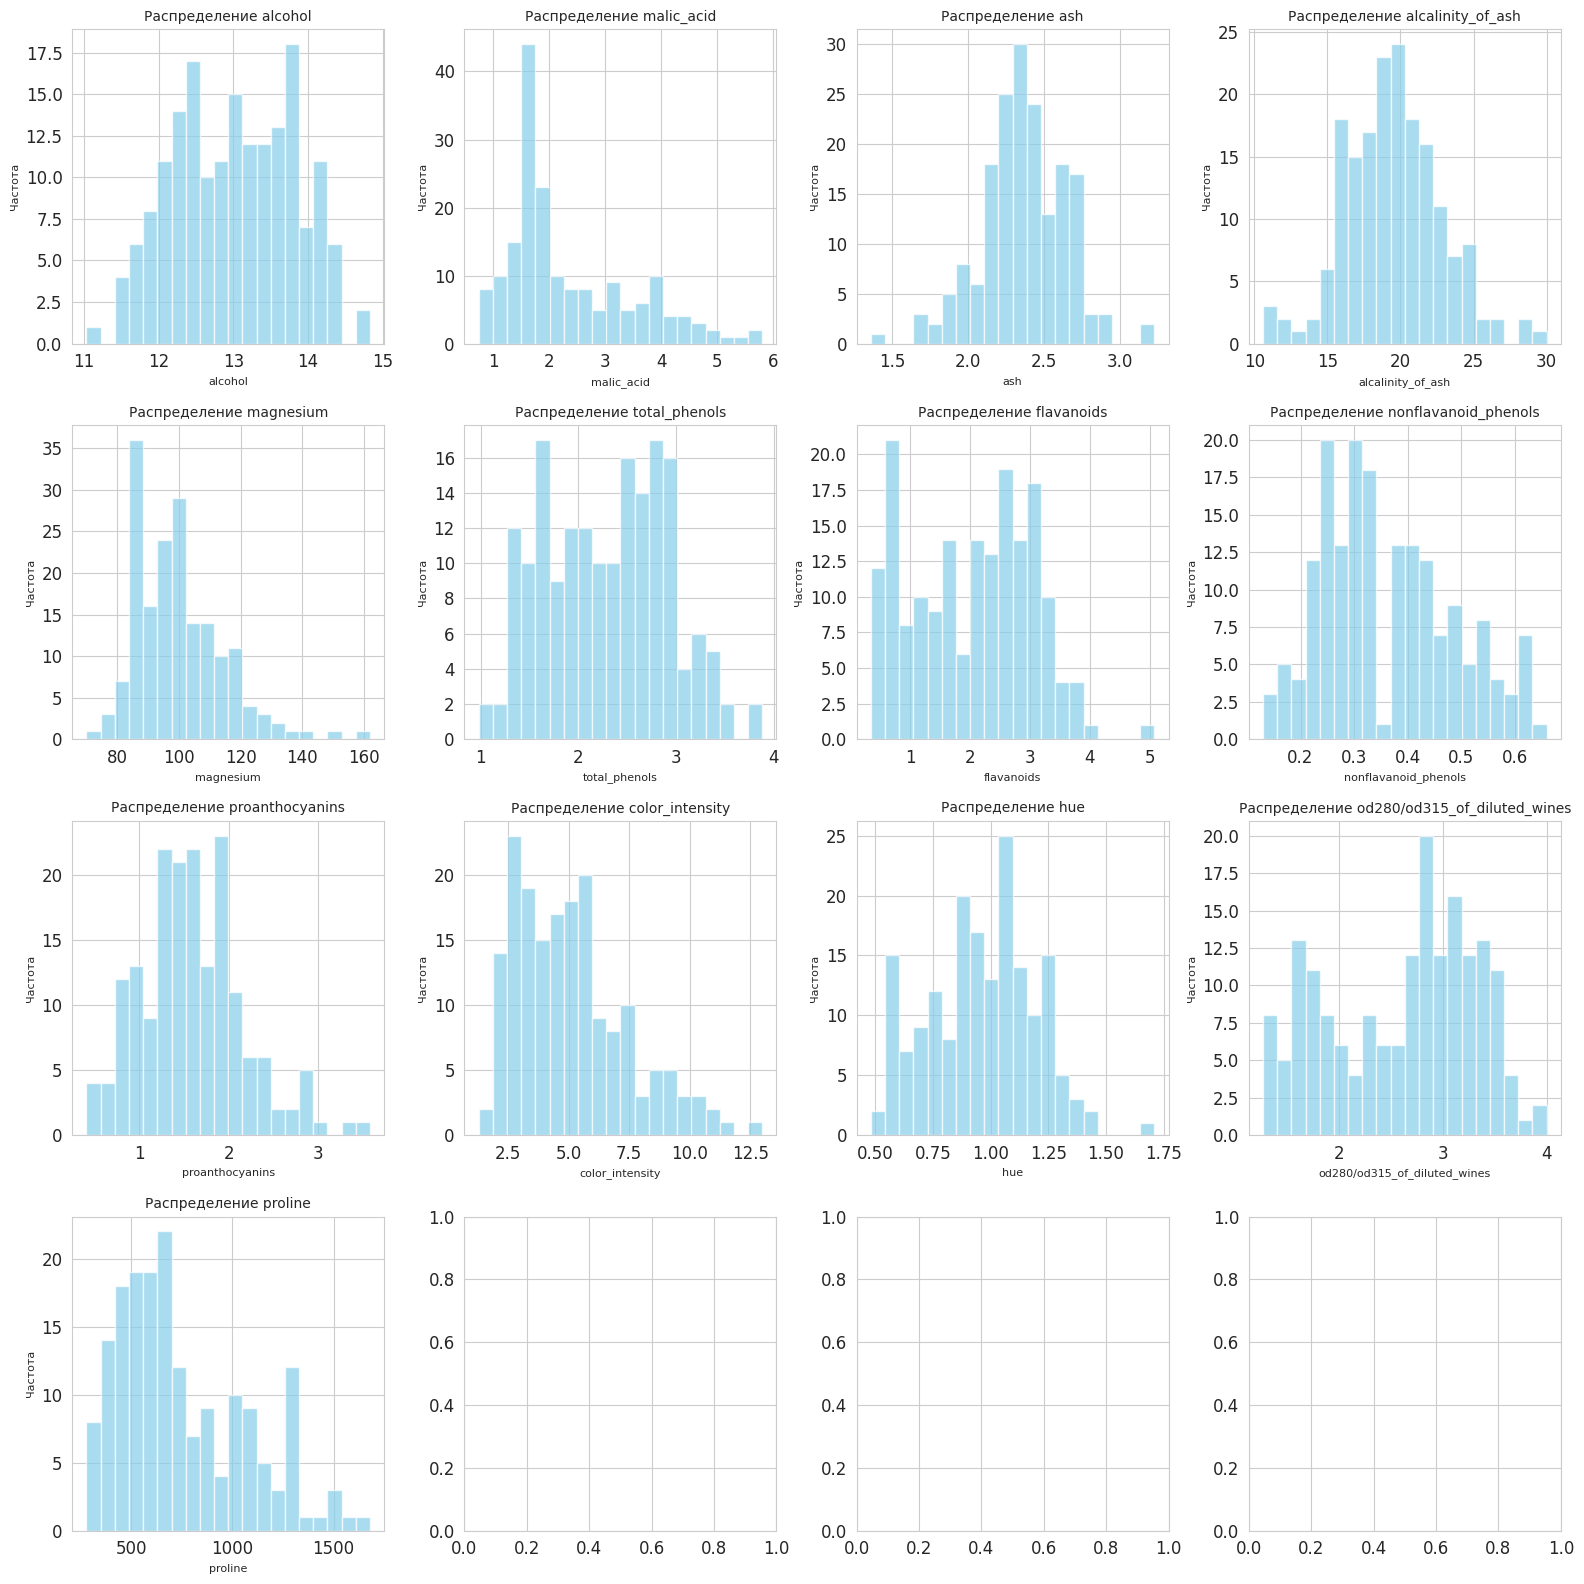

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for i, feature in enumerate(feature_names_wine[:len(axes)]):
    df_wine[feature].hist(bins=20, ax=axes[i], alpha=0.7, color='skyblue')
    axes[i].set_title(f'Распределение {feature}', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_ylabel('Частота', fontsize=8)

plt.tight_layout()
plt.show()

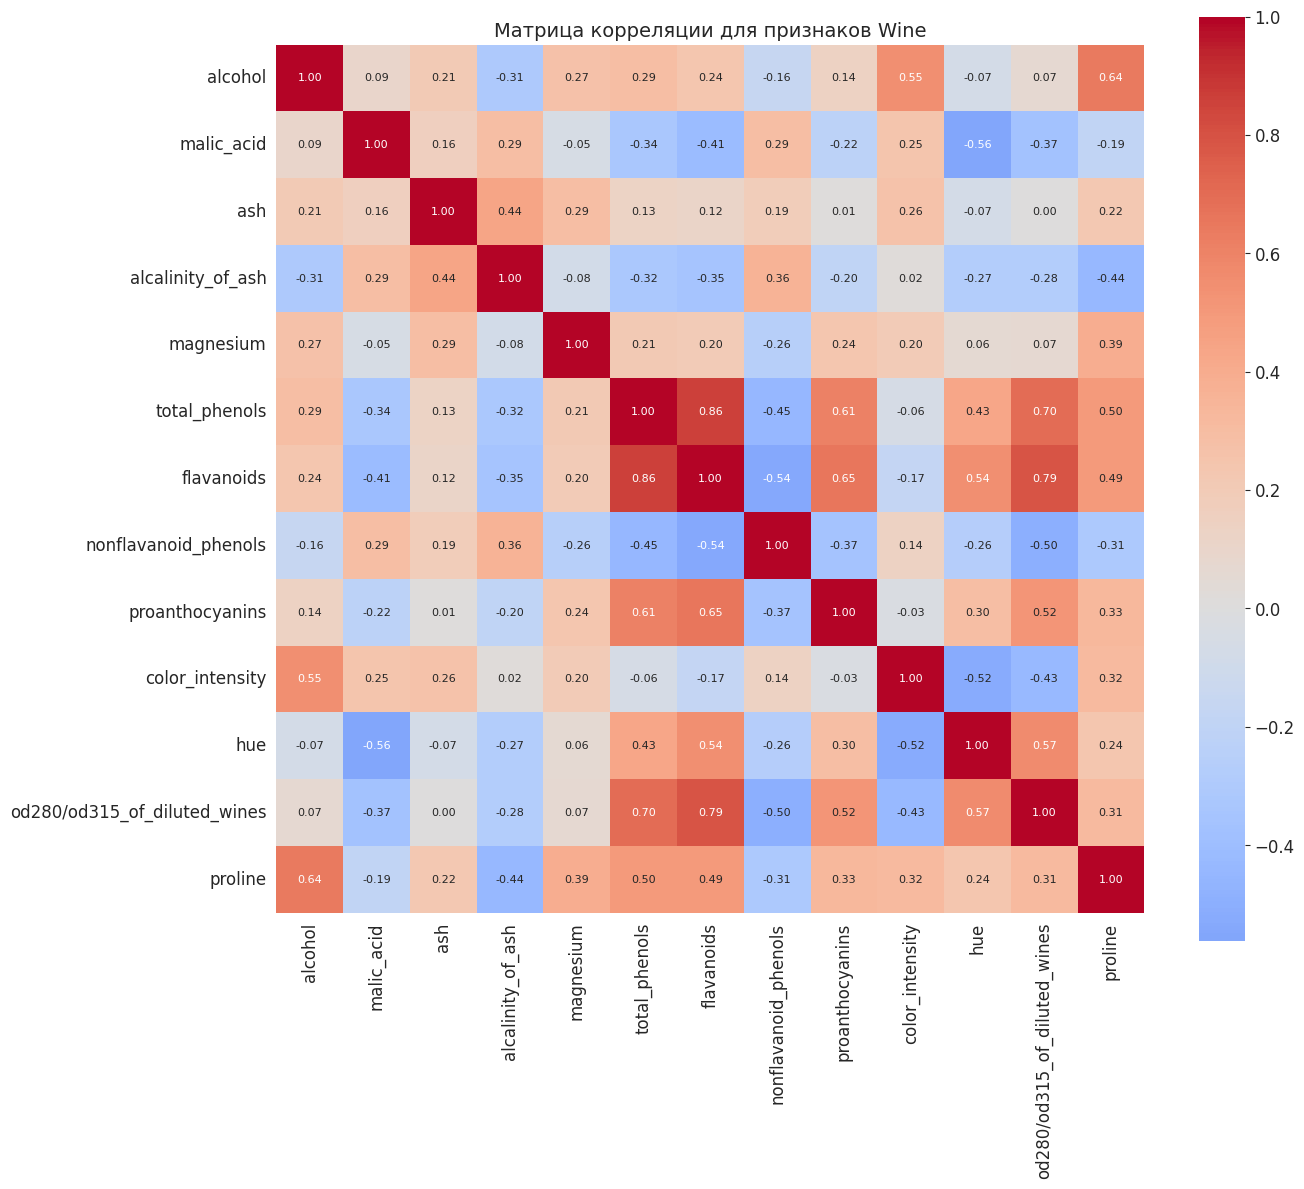

Размер обучающей выборки Wine: (142, 13)
Размер тестовой выборки Wine: (36, 13)


In [ ]:
plt.figure(figsize=(14, 12))
corr_matrix_wine = df_wine[feature_names_wine].corr()
sns.heatmap(corr_matrix_wine, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', annot_kws={'size': 8})
plt.title('Матрица корреляции для признаков Wine', fontsize=14)
plt.show()

# %%
# Разделение данных Wine (80/20)
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print(f"Размер обучающей выборки Wine: {X_train_wine.shape}")
print(f"Размер тестовой выборки Wine: {X_test_wine.shape}")

In [ ]:
k = 5

# Модель БЕЗ масштабирования
knn_no_scale = KNeighborsClassifier(n_neighbors=k)
knn_no_scale.fit(X_train_wine, y_train_wine)
y_pred_no_scale = knn_no_scale.predict(X_test_wine)
accuracy_no_scale = accuracy_score(y_test_wine, y_pred_no_scale)

# Модель С масштабированием
scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

knn_with_scale = KNeighborsClassifier(n_neighbors=k)
knn_with_scale.fit(X_train_wine_scaled, y_train_wine)
y_pred_with_scale = knn_with_scale.predict(X_test_wine_scaled)
accuracy_with_scale = accuracy_score(y_test_wine, y_pred_with_scale)

In [ ]:
print("=== СРАВНЕНИЕ МОДЕЛЕЙ НА WINE ===")
print(f"Точность БЕЗ масштабирования (k={k}): {accuracy_no_scale:.4f}")
print(f"Точность С масштабированием (k={k}): {accuracy_with_scale:.4f}")
print(f"Улучшение: {accuracy_with_scale - accuracy_no_scale:.4f}")

=== СРАВНЕНИЕ МОДЕЛЕЙ НА WINE ===
Точность БЕЗ масштабирования (k=5): 0.8056
Точность С масштабированием (k=5): 0.9722
Улучшение: 0.1667


In [ ]:
correlation_with_target = []
for feature in feature_names_wine:
    correlation = np.corrcoef(df_wine[feature], df_wine['target'])[0, 1]
    correlation_with_target.append((feature, abs(correlation)))

# Сортировка по убыванию корреляции
correlation_with_target.sort(key=lambda x: x[1], reverse=True)

print("\nВажность признаков (по абсолютной корреляции с целевой переменной):")
for feature, corr in correlation_with_target:
    print(f"{feature}: {corr:.4f}")


Важность признаков (по абсолютной корреляции с целевой переменной):
flavanoids: 0.8475
od280/od315_of_diluted_wines: 0.7882
total_phenols: 0.7192
proline: 0.6337
hue: 0.6174
alcalinity_of_ash: 0.5179
proanthocyanins: 0.4991
nonflavanoid_phenols: 0.4891
malic_acid: 0.4378
alcohol: 0.3282
color_intensity: 0.2657
magnesium: 0.2092
ash: 0.0496


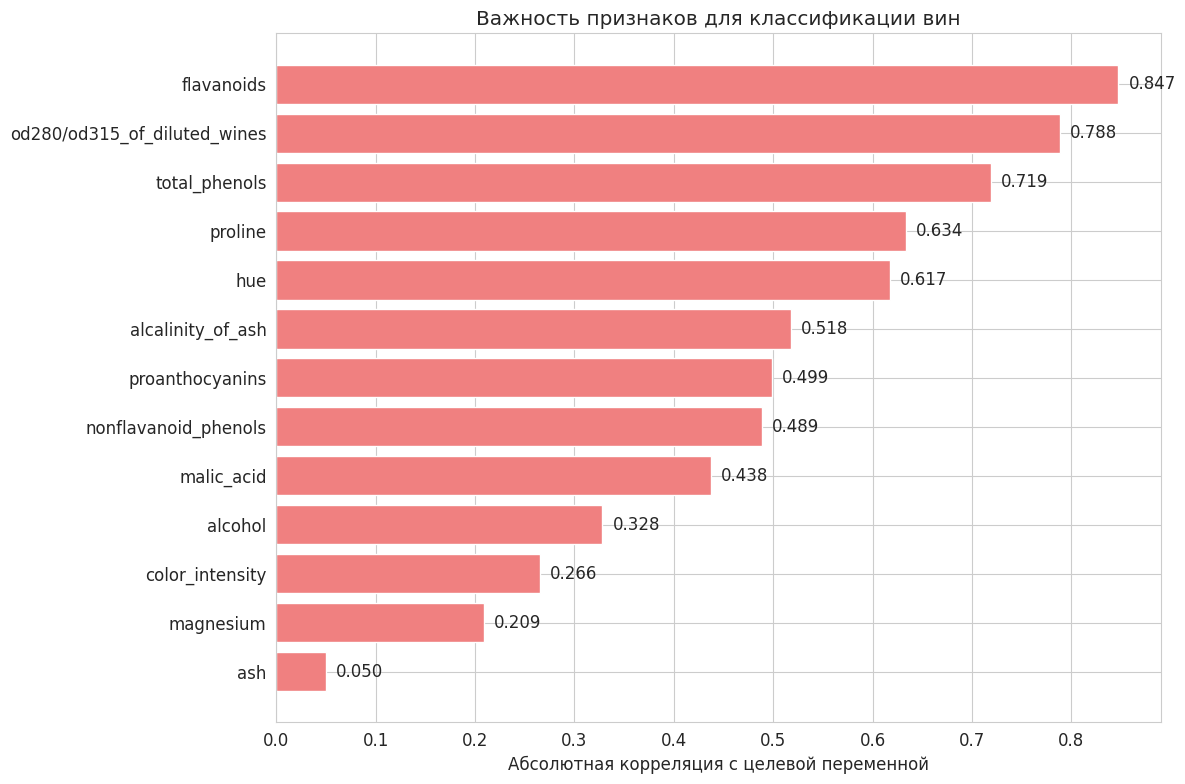

In [ ]:
features, correlations = zip(*correlation_with_target)

plt.figure(figsize=(12, 8))
bars = plt.barh(features, correlations, color='lightcoral')
plt.xlabel('Абсолютная корреляция с целевой переменной')
plt.title('Важность признаков для классификации вин')
plt.gca().invert_yaxis()

# Добавление значений на столбцы
for bar, corr in zip(bars, correlations):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{corr:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

In [ ]:
print("\n=== ПОЧЕМУ МАСШТАБИРОВАНИЕ ВЛИЯЕТ НА k-NN ===")
print("1. k-NN использует расстояния между точками")
print("2. Без масштабирования признаки с большими значениями (например, proline)")
print("   доминируют над признаками с малыми значениями (например, ash)")
print("3. Масштабирование выравнивает вклад всех признаков")
print("4. Евклидово расстояние становится более сбалансированным")

# Демонстрация различий в масштабах
print("\nДиапазоны значений признаков ДО масштабирования:")
for i, feature in enumerate(feature_names_wine[:5]):  # Покажем первые 5
    min_val = df_wine[feature].min()
    max_val = df_wine[feature].max()
    print(f"{feature}: [{min_val:.2f}, {max_val:.2f}]")


=== ПОЧЕМУ МАСШТАБИРОВАНИЕ ВЛИЯЕТ НА k-NN ===
1. k-NN использует расстояния между точками
2. Без масштабирования признаки с большими значениями (например, proline)
   доминируют над признаками с малыми значениями (например, ash)
3. Масштабирование выравнивает вклад всех признаков
4. Евклидово расстояние становится более сбалансированным

Диапазоны значений признаков ДО масштабирования:
alcohol: [11.03, 14.83]
malic_acid: [0.74, 5.80]
ash: [1.36, 3.23]
alcalinity_of_ash: [10.60, 30.00]
magnesium: [70.00, 162.00]


In [ ]:
X_train_wine_opt = X_train_wine_scaled
X_test_wine_opt = X_test_wine_scaled
y_train_wine_opt = y_train_wine
y_test_wine_opt = y_test_wine

In [ ]:
param_grid = {
    'n_neighbors': range(1, 25),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

print("Запуск GridSearchCV...")
grid_search.fit(X_train_wine_opt, y_train_wine_opt)

Запуск GridSearchCV...
Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 25),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [ ]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность при кросс-валидации:", grid_search.best_score_)

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'uniform'}
Лучшая точность при кросс-валидации: 0.9862068965517242


In [ ]:
best_knn_wine = grid_search.best_estimator_
y_pred_best_wine = best_knn_wine.predict(X_test_wine_opt)
best_accuracy = accuracy_score(y_test_wine_opt, y_pred_best_wine)

print(f"Точность на тестовой выборке: {best_accuracy:.4f}")

Точность на тестовой выборке: 1.0000


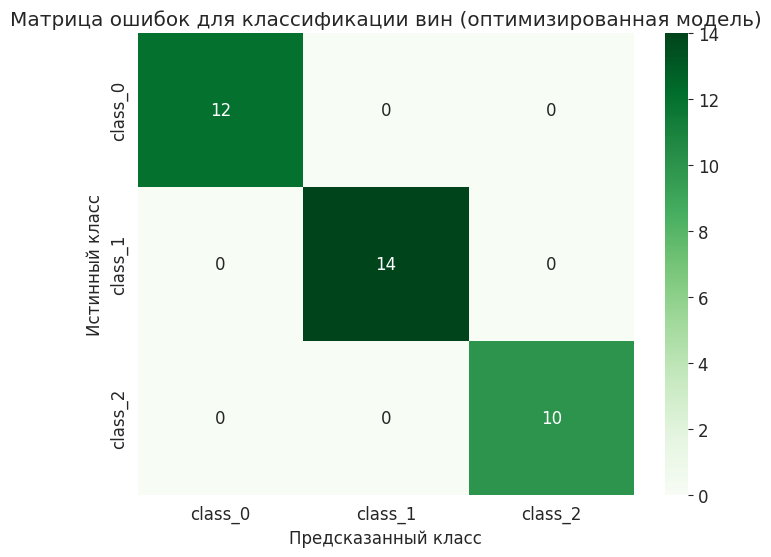

In [ ]:
cm_wine = confusion_matrix(y_test_wine_opt, y_pred_best_wine)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_wine, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names_wine,
            yticklabels=target_names_wine)
plt.title('Матрица ошибок для классификации вин (оптимизированная модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

In [ ]:
print("Отчет о классификации для оптимизированной модели:")
print(classification_report(y_test_wine_opt, y_pred_best_wine,
                          target_names=target_names_wine))

Отчет о классификации для оптимизированной модели:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [ ]:
# ROC-кривые и AUC для многоклассовой классификации
y_proba_wine = best_knn_wine.predict_proba(X_test_wine_opt)
y_test_bin_wine = label_binarize(y_test_wine_opt, classes=[0, 1, 2])
n_classes_wine = y_test_bin_wine.shape[1]

# Вычисление ROC и AUC для каждого класса
fpr_wine = dict()
tpr_wine = dict()
roc_auc_wine = dict()

for i in range(n_classes_wine):
    fpr_wine[i], tpr_wine[i], _ = roc_curve(y_test_bin_wine[:, i], y_proba_wine[:, i])
    roc_auc_wine[i] = auc(fpr_wine[i], tpr_wine[i])


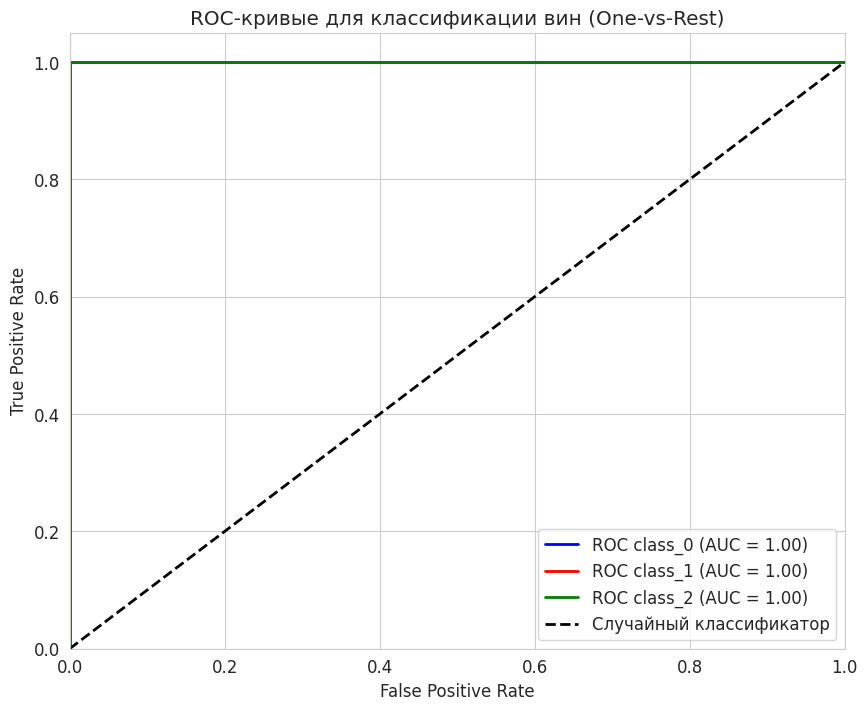

In [ ]:
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green'])

for i, color in zip(range(n_classes_wine), colors):
    plt.plot(fpr_wine[i], tpr_wine[i], color=color, lw=2,
             label=f'ROC {target_names_wine[i]} (AUC = {roc_auc_wine[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для классификации вин (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
print("Значения AUC для каждого класса:")
for i in range(n_classes_wine):
    print(f"{target_names_wine[i]}: {roc_auc_wine[i]:.3f}")

Значения AUC для каждого класса:
class_0: 1.000
class_1: 1.000
class_2: 1.000


In [ ]:
print("\nАнализ важности признаков методом исключения:")

base_accuracy = best_accuracy
feature_importance = []

for i, feature in enumerate(feature_names_wine):
    # Создаем копию данных без одного признака
    indices = [j for j in range(len(feature_names_wine)) if j != i]
    X_reduced = X_train_wine_opt[:, indices]
    X_test_reduced = X_test_wine_opt[:, indices]

    # Обучаем модель на уменьшенных данных
    knn_reduced = KNeighborsClassifier(**grid_search.best_params_)
    knn_reduced.fit(X_reduced, y_train_wine_opt)
    y_pred_reduced = knn_reduced.predict(X_test_reduced)
    accuracy_reduced = accuracy_score(y_test_wine_opt, y_pred_reduced)

    importance = base_accuracy - accuracy_reduced
    feature_importance.append((feature, importance))

# Сортировка по важности
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nВлияние удаления признаков на точность:")
for feature, importance in feature_importance:
    change = "ухудшение" if importance > 0 else "улучшение"
    print(f"{feature}: {importance:+.4f} ({change})")


Анализ важности признаков методом исключения:

Влияние удаления признаков на точность:
alcohol: +0.0833 (ухудшение)
proline: +0.0556 (ухудшение)
ash: +0.0278 (ухудшение)
alcalinity_of_ash: +0.0278 (ухудшение)
magnesium: +0.0278 (ухудшение)
total_phenols: +0.0278 (ухудшение)
flavanoids: +0.0278 (ухудшение)
malic_acid: +0.0000 (улучшение)
nonflavanoid_phenols: +0.0000 (улучшение)
proanthocyanins: +0.0000 (улучшение)
color_intensity: +0.0000 (улучшение)
hue: +0.0000 (улучшение)
od280/od315_of_diluted_wines: +0.0000 (улучшение)


In [ ]:
class KNearestNeighbours:
    def __init__(self, n_neighbours=5):
        self.n_neighbours = n_neighbours

    def fit(self, X, y):
        """
        Сохраняет обучающие данные
        X: array-like, shape (n_samples, n_features)
        y: array-like, shape (n_samples,)
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def euclidean_distance(self, a, b):
        """Вычисление евклидова расстояния между двумя точками"""
        return np.sqrt(np.sum((a - b) ** 2))

    def predict(self, X):
        """
        Предсказание классов для входных данных
        X: array-like, shape (n_samples, n_features)
        Returns: array, shape (n_samples,)
        """
        X_test = np.array(X)
        predictions = []

        for i, x in enumerate(X_test):
            # Вычисление расстояний до всех точек обучающей выборки
            distances = []
            for j, x_train in enumerate(self.X_train):
                dist = self.euclidean_distance(x, x_train)
                distances.append((dist, self.y_train[j]))

            # Сортировка по расстоянию и выбор k ближайших соседей
            distances.sort(key=lambda x: x[0])
            nearest_neighbours = distances[:self.n_neighbours]

            # Голосование: выбор наиболее частого класса
            neighbour_classes = [neighbour[1] for neighbour in nearest_neighbours]
            prediction = max(set(neighbour_classes), key=neighbour_classes.count)
            predictions.append(prediction)

        return np.array(predictions)